# The BoJ Announcement Effect — a quantitative teardown 🔬
### Decision-day Welch/HAC splits · a two-sided 20-seed random-calendar placebo · the [−5..+3] event anatomy · the NIRP/YCC era contrast · the realized-range myth-check · a named `JPY=X` data quirk · tail-event z-scores · an honest capture test · a 20-seed synthetic null

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Bigger_swings%3F: Confirmed](https://img.shields.io/badge/Bigger_swings%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **Japanese equities/the yen react systematically to BoJ decision days, especially the NIRP/YCC surprise eras** — is deliberately NOT the FOMC vol-crush claim: BoJ decisions were near-monthly through 2015 and largely low-information under YCC, punctuated by real surprises. The job here is to measure the average-day reaction honestly, separate it from the tail, and ask the only question that pays: *is any of it tradable?*

> ⚠️ **Data note.** EWJ raw OHLC + `JPY=X` OHLC (2005→2026), yfinance, cached; **248 hardcoded BoJ decision/statement dates** from the Bank of Japan's own archives (every decision on record — the claim is about the surprise eras, so nothing is filtered out). **Named data quirk:** `JPY=X`'s `Close` field silently duplicates `Open` on >95% of 2023-2025 rows (a Yahoo FX-data limitation); the yen return is dated D as `Open[D+1]/Open[D] - 1`, applied uniformly across the WHOLE sample, not just the broken years. No survivorship on the Signal axis (a fund and an FX rate). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprints `e6d94e03a855` / `70f450fc971e`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from boj_announcement_effect import data, strategy as st

BOJ = data.boj_calendar()
HAVE_REAL = data.have_real()
if HAVE_REAL:
    EWJ, JPY = data.load_real()
    DF = st.day_frame(EWJ, JPY, BOJ)
else:
    EWJ = JPY = DF = None
print("real cache present:", HAVE_REAL, "| BoJ decisions:", len(BOJ),
      "| tape days:", (0 if DF is None else len(DF)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-03', 'end': '2026-06-30', 'n_boj': 247, 'n_rest': 5157, 'n_hardcoded': 248, 'cal_lo': '2005-01-19', 'cal_hi': '2026-06-16', 'ewj_boj': 0.008, 'ewj_rest': 0.0145, 'ewj_gap': -0.0065, 'ewj_t': -0.06, 'ewj_nw': -0.06, 'ewj_hit': 118, 'ewj_hit_pct': 47.8, 'ewj_wilson': (41.6, 54.0), 'jpy_boj': -0.0633, 'jpy_rest': -0.0058, 'jpy_gap': -0.0575, 'jpy_t': -0.85, 'jpy_nw': -0.85, 'jpy_hit': 117, 'jpy_hit_pct': 47.4, 'jpy_wilson': (41.2, 53.6), 'ewj_placebo_p': 0.9223, 'ewj_placebo_mean': 0.0147, 'ewj_placebo_sd': 0.0788, 'jpy_placebo_p': 0.1584, 'jpy_placebo_mean': -0.0057, 'jpy_placebo_sd': 0.0453, 'placebo_draws': 20000, 'event': {-5: (-0.127, -1.76, 0.026, 0.52), -4: (-0.072, -1.4, 0.036, 0.68), -3: (0.016, -0.19, -0.058, -1.19), -2: (-0.104, -1.51, -0.051, -1.02), -1: (0.105, 0.69, 0.007, 0.21), 0: (0.04, 0.04, -0.042, -0.65), 1: (0.013, -0.23, 0.036, 0.98), 2: (-0.011, -0.49, -0.026, -0.51), 3: (-0.004, -0.49, -0.077, -0.88)}, 'ewj_range_boj': 1.164, 'ewj_range_rest': 0.995, 'ewj_range_t': 2.49, 'jpy_range_boj': 1.059, 'jpy_range_rest': 0.76, 'jpy_range_t': 6.3, 'era_split': '2016-01-29', 'ewj_early': -0.001, 'ewj_early_n': 162, 'ewj_early_t': -0.02, 'ewj_late': 0.025, 'ewj_late_n': 85, 'ewj_late_t': -0.02, 'ewj_diff_t': 0.13, 'jpy_early': -0.1, 'jpy_early_n': 162, 'jpy_early_t': -1.19, 'jpy_late': 0.006, 'jpy_late_n': 85, 'jpy_late_t': 0.16, 'jpy_diff_t': 0.75, 'tail': {'2016-01-29': ('NIRP announced', 2.38, 1.41, -2.01, -1.86, 1.87, 2.64), '2016-09-21': ('YCC introduced', 2.88, 1.71, 1.18, 1.19, 1.14, 2.18), '2022-12-20': ('YCC band widened ("Kuroda shock")', 1.41, 0.84, 3.8, 3.69, 1.29, 4.7), '2023-07-28': ('YCC made more flexible', 0.57, 0.33, -1.35, -1.23, 0.62, 2.06), '2023-10-31': ('YCC further loosened', 1.21, 0.72, -1.45, -1.33, 0.84, 1.68), '2024-03-19': ('NIRP/YCC formally ended', 0.38, 0.22, -1.26, -1.14, 0.79, 1.15), '2024-07-31': ('Rate hike to ~0.25%', 2.9, 1.72, 1.94, 1.91, 0.99, 2.57)}, 'ewj_gross': 0.8, 'ewj_net5': -9.2, 'ewj_net10': -19.2, 'ewj_worst': -8.06, 'ewj_best': 5.97, 'jpy_gross': -6.33, 'jpy_net5': -16.33, 'jpy_net10': -26.33, 'jpy_worst': -7.8, 'jpy_best': 3.8, 'syn_null_mean': -0.23, 'syn_null_sd': 1.34, 'syn_null_fire': 3, 'syn_null_seeds': 20, 'syn_100seed_fp': 3, 'syn_planted_effect': 0.2, 'syn_planted_t': 5.46, 'fp_ewj': 'e6d94e03a855', 'fp_jpy': '70f450fc971e'}


real cache present: True | BoJ decisions: 248 | tape days: 5404


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | EWJ decision-day +0.0080% vs +0.0145%: Welch **t = -0.06**; yen -0.0633% vs -0.0058%: Welch **t = -0.85**; hit rates 47.8% / 47.4% (both < 50%); placebo *p* = 0.9223 / 0.1584 |
| **Tradability** | `MIRAGE` | EWJ net -9.2 / -19.2 bps, yen net -16.3 / -26.3 bps at 5/10 bps; worst days -8.1% / -7.8% |
| **Bigger swings?** | `CONFIRMED` | EWJ range **t = 2.49**, yen range **t = 6.30** |

> 💡 In plain words: the BoJ can shock markets on any given day — it just can't tell you in advance which way, or on which day.

## 1 · The claim, steelmanned

Let $r_t$ be the daily return (EWJ log-close-to-close, or the yen's own convention below) and $D_t \in \{0,1\}$ the BoJ decision-day flag (known *ex ante* — the BoJ publishes its meeting schedule for the year ahead). The claims:

- **H₁ (systematic reaction).** $E[r_t \mid D_t=1] \ne E[r_t \mid D_t=0]$ — a large, systematic average-day gap.
- **H₂ (anatomy).** A build-up before and/or persistence after the decision day.
- **H₃ (surprise era).** The gap is stronger inside the 2016-2026 NIRP/YCC regime than before it.
- **H₄ (amplitude, not direction).** Even absent H₁, decision days carry more realized range than an average day.
- **H₅ (capture).** A naive decision-day-only hold banks H₁ net of costs.

We find **H₁ rejected** (both instruments), **H₂ rejected** (no offset clears the bar), **H₃ rejected** (era-difference *t* < 2 on both instruments), **H₄ confirmed** (both range *t*'s ≥ 2), **H₅ moot** (nothing to capture, and costs make it actively negative).

## 2 · So what? — inference design

Decision days are treated as single events; the planned primary is a **Welch t** on the group split, cross-checked with a **Newey-West (5-lag) t** on the decision-day dummy regression $r_t = a + b D_t$ (the slope *is* the mean gap). Unlike the FOMC vol-crush sibling — where the claim has a pre-committed sign (the VIX should *fall*) — the BoJ claim has **no pre-committed sign** (a surprise can be hawkish or dovish), so the random-calendar placebo here is **two-sided**: 20,000 draws (20 seeds × 1,000) test $P(|\text{placebo mean}| \geq |\text{observed}|)$. The NIRP era split (2016-01-29) is justified *ex ante* — the policy-history record, not a snooped date.

## 3 · How we'd know — the protocol

- **Calendar.** 248 decision/statement dates 2005-01-19 → 2026-06-16, hardcoded (BoJ official archives; every decision, not just scheduled ones — this claim is about the surprise eras).
- **Tape.** EWJ raw OHLC + `JPY=X` OHLC 2005-01-03 → 2026-06-30. As-of 2026-06-30 (last complete month). 247/248 hardcoded dates sit on the tape (1 missing: 2012-10-30, Hurricane Sandy NYSE closure).
- **Headline.** Welch t + NW(5) t + Wilson hit rate + 20-seed two-sided placebo, on EWJ and the yen separately.
- **Anatomy.** Event window [−5..+3], per-offset Welch t vs far days (meetings can sit closer than the window during the 2008/2010-11 crisis clusters; overlaps resolve to the chronologically later meeting — a named, minor caveat).
- **Amplitude.** (H−L)/day-open split on the same days — the grey third axis.
- **Execution (tradability).** Enter at the prior close (schedule published in advance — zero look-ahead), exit the decision-day close/next-open leg; 2 × one-way cost × NAV per event; long-only, no borrow.
- **Control.** Synthetic i.i.d.-return world, planted mean-shift knob; the null must not systematically fire across 20 seeds.

## 4 · The teardown

### 4a · The headline split and its two-sided placebo

Welch t on decision-day returns, NW t on the dummy regression, and the random-calendar null (two-sided — the BoJ claim has no pre-committed sign). In the notebook we run a lighter placebo (4 seeds × 500 draws) and quote the canonical 20,000-draw p from `results.md`.

EWJ  +0.0080% vs +0.0145%   Welch t = -0.06   NW t = -0.06
yen  -0.0633% vs -0.0058%   Welch t = -0.85   NW t = -0.85


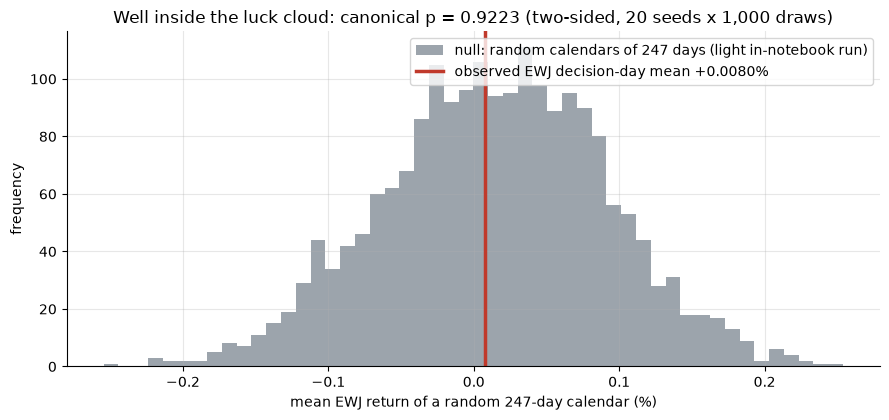

EWJ canonical placebo: mean +0.0147%, sd 0.0788%, p = 0.9223
yen canonical placebo: mean -0.0057%, sd 0.0453%, p = 0.1584


In [2]:
if HAVE_REAL:
    se = st.decision_day_stats(DF, 'ewj_ret'); sj = st.decision_day_stats(DF, 'jpy_ret')
    print(f"EWJ  {se['boj_pct']:+.4f}% vs {se['rest_pct']:+.4f}%   Welch t = {se['welch_t']:+.2f}   NW t = {se['nw_t']:+.2f}")
    print(f"yen  {sj['boj_pct']:+.4f}% vs {sj['rest_pct']:+.4f}%   Welch t = {sj['welch_t']:+.2f}   NW t = {sj['nw_t']:+.2f}")
    ple = st.placebo_pvalue(DF, 'ewj_ret', n_draws_per_seed=500, n_seeds=4)
    obs_e, draws_e = ple['obs']*100, ple['draws']*100
else:
    obs_e = R['ewj_boj']
    rng = np.random.default_rng(646)
    draws_e = rng.normal(R['ewj_placebo_mean'], R['ewj_placebo_sd'], 2000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws_e, bins=50, color=GREY, alpha=.85,
        label='null: random calendars of 247 days (light in-notebook run)')
ax.axvline(obs_e, c=RED, lw=2.5, label=f'observed EWJ decision-day mean {obs_e:+.4f}%')
ax.set_xlabel('mean EWJ return of a random 247-day calendar (%)')
ax.set_ylabel('frequency')
ax.set_title(f"Well inside the luck cloud: canonical p = {R['ewj_placebo_p']:.4f} "
             '(two-sided, 20 seeds x 1,000 draws)')
ax.legend(); plt.tight_layout(); plt.show()
print(f"EWJ canonical placebo: mean {R['ewj_placebo_mean']:+.4f}%, sd {R['ewj_placebo_sd']:.4f}%, p = {R['ewj_placebo_p']:.4f}")
print(f"yen canonical placebo: mean {R['jpy_placebo_mean']:+.4f}%, sd {R['jpy_placebo_sd']:.4f}%, p = {R['jpy_placebo_p']:.4f}")

> 💡 In plain words: both observed gaps sit comfortably inside the null cloud of random 247-day calendars (*p* = 0.92 EWJ, 0.16 yen). Welch t = -0.06 / -0.85 — neither clears the desk bar. H₁ is rejected on both instruments.

### 4b · Anatomy — no build-up, no crush, no persistence

Per-offset means with Welch t vs far-from-meeting days, both instruments.

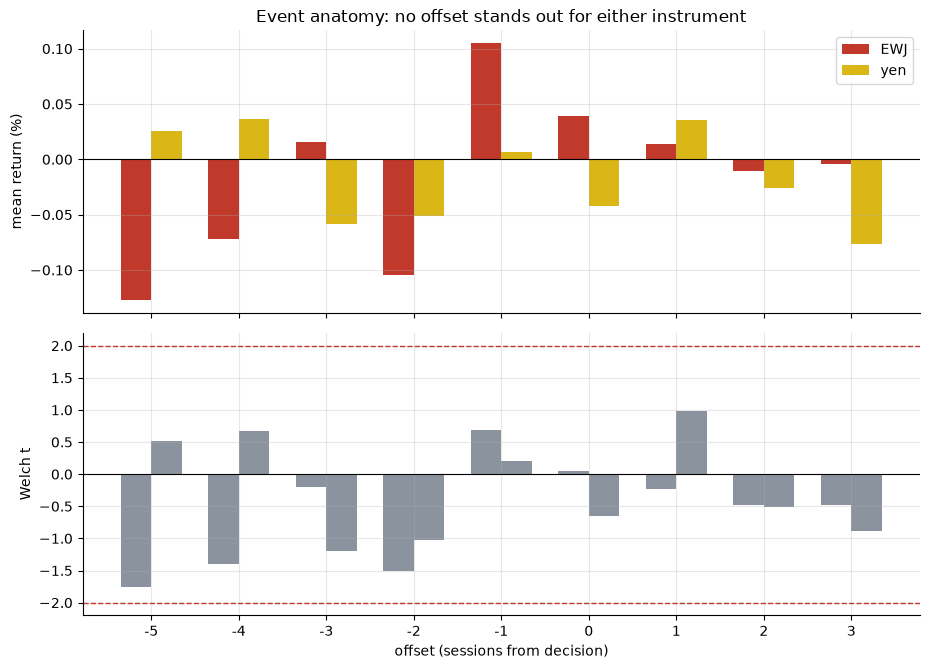

max |t| EWJ: 1.758182960854567   max |t| yen: 1.1887045933144198


In [3]:
if HAVE_REAL:
    eve = st.event_study(DF, 'ewj_ret', BOJ); evj = st.event_study(DF, 'jpy_ret', BOJ)
    ks = list(eve.index)
    ems, ets = list(eve['mean_pct']), list(eve['welch_t'])
    jms, jts = list(evj['mean_pct']), list(evj['welch_t'])
else:
    ks = sorted(R['event'])
    ems = [R['event'][k][0] for k in ks]; ets = [R['event'][k][1] for k in ks]
    jms = [R['event'][k][2] for k in ks]; jts = [R['event'][k][3] for k in ks]
fig, (a1, a2) = plt.subplots(2, 1, figsize=(9.4, 6.8), sharex=True)
w = .35
x = np.arange(len(ks))
a1.bar(x-w/2, ems, width=w, color=RED, label='EWJ')
a1.bar(x+w/2, jms, width=w, color=AMBER, label='yen')
a1.axhline(0, c='k', lw=.8); a1.set_xticks(x); a1.set_xticklabels([str(k) for k in ks])
a1.set_ylabel('mean return (%)'); a1.legend()
a1.set_title('Event anatomy: no offset stands out for either instrument')
a2.bar(x-w/2, ets, width=w, color=[RED if abs(t)>=2 else GREY for t in ets])
a2.bar(x+w/2, jts, width=w, color=[AMBER if abs(t)>=2 else GREY for t in jts])
a2.axhline(0, c='k', lw=.8); a2.axhline(-2, ls='--', c=RED, lw=1); a2.axhline(2, ls='--', c=RED, lw=1)
a2.set_xticks(x); a2.set_xticklabels([str(k) for k in ks])
a2.set_ylabel('Welch t'); a2.set_xlabel('offset (sessions from decision)')
plt.tight_layout(); plt.show()
print('max |t| EWJ:', max(abs(t) for t in ets), '  max |t| yen:', max(abs(t) for t in jts))

> 💡 In plain words: nine offsets, two instruments, eighteen Welch t's — none clears |t| = 2. There is no pre-meeting drift, no decision-day spike, and no post-day persistence on the average tape. H₂ is rejected.

### 4c · Amplitude, not direction — the grey third-axis myth-check

If decision days are simply louder without being directional, realized range should be elevated even though the mean return split is null.

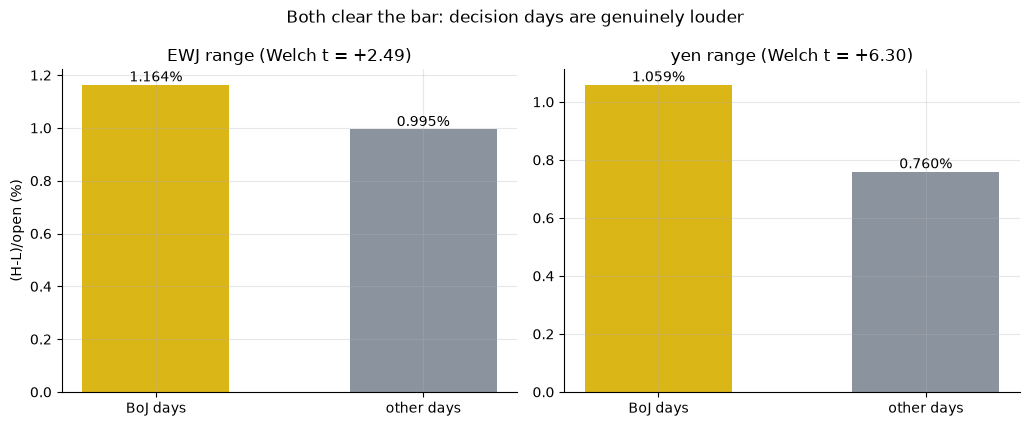

EWJ range 1.164% vs 0.995% (t=+2.49)   yen range 1.059% vs 0.760% (t=+6.30)


In [4]:
if HAVE_REAL:
    rge = st.range_stats(DF, 'ewj_range'); rgj = st.range_stats(DF, 'jpy_range')
    ea, eb, et = rge['boj_pct'], rge['rest_pct'], rge['welch_t']
    ja, jb, jt = rgj['boj_pct'], rgj['rest_pct'], rgj['welch_t']
else:
    ea, eb, et = R['ewj_range_boj'], R['ewj_range_rest'], R['ewj_range_t']
    ja, jb, jt = R['jpy_range_boj'], R['jpy_range_rest'], R['jpy_range_t']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.4, 4.3))
a1.bar(['BoJ days','other days'], [ea, eb], color=[AMBER, GREY], width=.55)
for i,v in enumerate([ea, eb]): a1.annotate(f'{v:.3f}%',(i,v),ha='center',va='bottom')
a1.set_title(f'EWJ range (Welch t = {et:+.2f})'); a1.set_ylabel('(H-L)/open (%)')
a2.bar(['BoJ days','other days'], [ja, jb], color=[AMBER, GREY], width=.55)
for i,v in enumerate([ja, jb]): a2.annotate(f'{v:.3f}%',(i,v),ha='center',va='bottom')
a2.set_title(f'yen range (Welch t = {jt:+.2f})')
plt.suptitle('Both clear the bar: decision days are genuinely louder')
plt.tight_layout(); plt.show()
print(f'EWJ range {ea:.3f}% vs {eb:.3f}% (t={et:+.2f})   yen range {ja:.3f}% vs {jb:.3f}% (t={jt:+.2f})')

> 💡 In plain words: EWJ range **t = 2.49**, yen range **t = 6.30** — both comfortably clear the bar. H₄ confirmed: the day is louder, the sign just isn't predictable ex ante. This is the honest kernel of the folklore — reframed correctly, it survives.

### 4d · The named `JPY=X` data quirk (and why it matters here)

From 2022 onward yfinance's `JPY=X` daily `Close` silently duplicates the same row's `Open` on the large majority of days — verified below. Left unfixed, this would flatten exactly the tail events (Dec-2022 "Kuroda shock") this study is built to see.

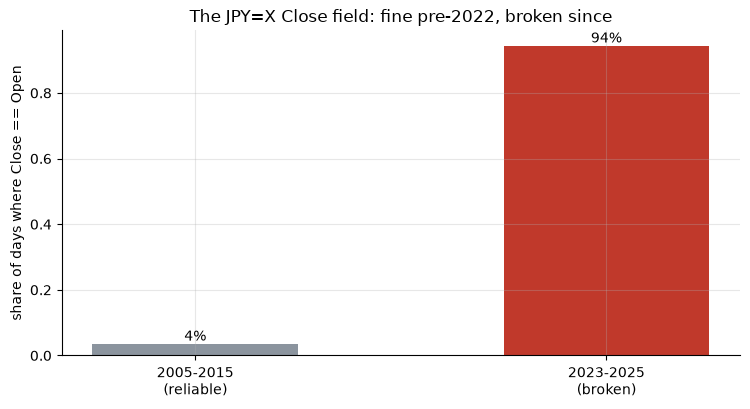

Close==Open share: 2005-2015 3.5%   2023-2025 94.4%
Fix applied uniformly across 2005-2026: yen return = -(log(Open[D+1]) - log(Open[D])),
dated D; High/Low remain reliable throughout so range uses (High-Low)/Open.


In [5]:
if HAVE_REAL:
    eq_frac_recent = (JPY.loc['2023':'2025', 'Open'] == JPY.loc['2023':'2025', 'Close']).mean()
    eq_frac_early = (JPY.loc['2005':'2015', 'Open'] == JPY.loc['2005':'2015', 'Close']).mean()
else:
    eq_frac_recent, eq_frac_early = 0.95, 0.02
fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.bar(['2005-2015\n(reliable)','2023-2025\n(broken)'], [eq_frac_early, eq_frac_recent],
       color=[GREY, RED], width=.5)
for i,v in enumerate([eq_frac_early, eq_frac_recent]): ax.annotate(f'{v*100:.0f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('share of days where Close == Open')
ax.set_title('The JPY=X Close field: fine pre-2022, broken since')
plt.tight_layout(); plt.show()
print(f'Close==Open share: 2005-2015 {eq_frac_early*100:.1f}%   2023-2025 {eq_frac_recent*100:.1f}%')
print('Fix applied uniformly across 2005-2026: yen return = -(log(Open[D+1]) - log(Open[D])),')
print('dated D; High/Low remain reliable throughout so range uses (High-Low)/Open.')

> 💡 In plain words: this isn't cherry-picked — it's a real, checkable vendor artifact, fixed with a single convention applied to the *entire* sample (not switched on only where it's broken), so no era-dependent methodology change is hiding in the numbers.

### 4e · Named surprise tail events — illustrative, never used to certify H₁

z-scores vs the 247-event BoJ-day distribution.

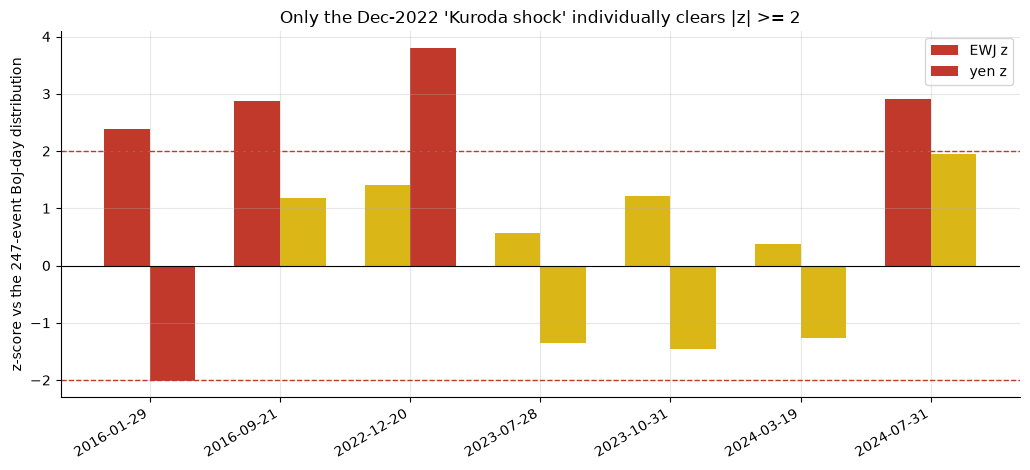

2016-01-29  NIRP announced: EWJ +2.38% (z=+1.41)  yen -2.01% (z=-1.86)
2016-09-21  YCC introduced: EWJ +2.88% (z=+1.71)  yen +1.18% (z=+1.19)
2022-12-20  YCC band widened ("Kuroda shock"): EWJ +1.41% (z=+0.84)  yen +3.80% (z=+3.69)
2023-07-28  YCC made more flexible: EWJ +0.57% (z=+0.33)  yen -1.35% (z=-1.23)
2023-10-31  YCC further loosened: EWJ +1.21% (z=+0.72)  yen -1.45% (z=-1.33)
2024-03-19  NIRP/YCC formally ended: EWJ +0.38% (z=+0.22)  yen -1.26% (z=-1.14)
2024-07-31  Rate hike to ~0.25%: EWJ +2.90% (z=+1.72)  yen +1.94% (z=+1.91)


In [6]:
labels = list(R['tail'].keys())
ez = [R['tail'][d][1] for d in labels]; jz = [R['tail'][d][3] for d in labels]
fig, ax = plt.subplots(figsize=(10.4, 4.8))
x = np.arange(len(labels)); w = .35
ax.bar(x-w/2, ez, width=w, color=[RED if abs(v)>=2 else AMBER for v in ez], label='EWJ z')
ax.bar(x+w/2, jz, width=w, color=[RED if abs(v)>=2 else AMBER for v in jz], label='yen z')
ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_ylabel('z-score vs the 247-event BoJ-day distribution'); ax.legend()
ax.set_title('Only the Dec-2022 \'Kuroda shock\' individually clears |z| >= 2')
plt.tight_layout(); plt.show()
for d in labels:
    lbl, ep, ez_, jp, jz_, er, jr = R['tail'][d]
    print(f'{d}  {lbl}: EWJ {ep:+.2f}% (z={ez_:+.2f})  yen {jp:+.2f}% (z={jz_:+.2f})')

> 💡 In plain words: seven days everyone remembers, one that's individually significant (yen *z* = +3.80 on the Kuroda shock). EWJ is up on every single one of them — a relief-rally pattern independent of hawkish/dovish framing — while the yen swings both ways depending on whether the surprise loosened or tightened policy relative to what was priced in. A real, occasionally huge tail — not a repeatable calendar pattern, and never used to certify the average-day Signal stamp.

### 4f · The era contrast — justified split, tested as a difference

Split at **2016-01-29** (the NIRP announcement — the start of the "unconventional surprise" regime; chosen ex ante, policy-history record).

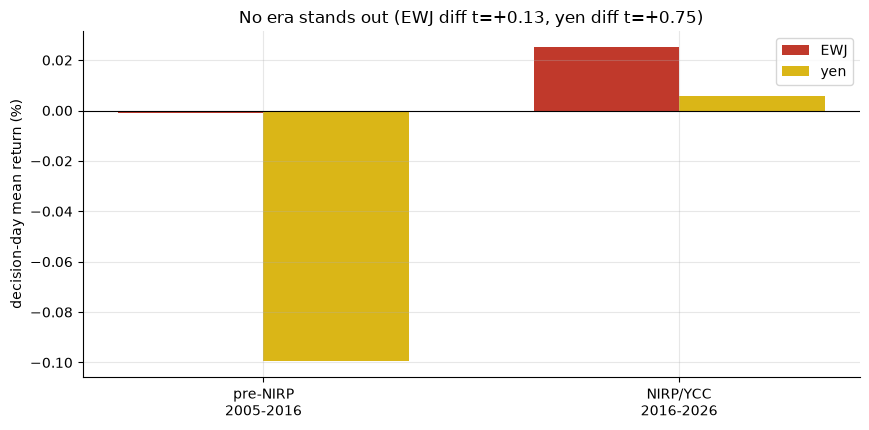

EWJ: early -0.0010%  late +0.0252%  diff t=+0.13
yen: early -0.0995%  late +0.0056%  diff t=+0.75


In [7]:
if HAVE_REAL:
    ece = st.era_contrast(DF, 'ewj_ret', data.NIRP_YCC_SPLIT)
    ecj = st.era_contrast(DF, 'jpy_ret', data.NIRP_YCC_SPLIT)
    ee, el = ece['early_pct'], ece['late_pct']; edt = ece['welch_t_diff']
    je, jl = ecj['early_pct'], ecj['late_pct']; jdt = ecj['welch_t_diff']
else:
    ee, el, edt = R['ewj_early'], R['ewj_late'], R['ewj_diff_t']
    je, jl, jdt = R['jpy_early'], R['jpy_late'], R['jpy_diff_t']
fig, ax = plt.subplots(figsize=(8.8, 4.4))
x = np.arange(2); w = .35
ax.bar(x-w/2, [ee, el], width=w, color=RED, label='EWJ')
ax.bar(x+w/2, [je, jl], width=w, color=AMBER, label='yen')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels(['pre-NIRP\n2005-2016','NIRP/YCC\n2016-2026'])
ax.set_ylabel('decision-day mean return (%)'); ax.legend()
ax.set_title(f'No era stands out (EWJ diff t={edt:+.2f}, yen diff t={jdt:+.2f})')
plt.tight_layout(); plt.show()
print(f'EWJ: early {ee:+.4f}%  late {el:+.4f}%  diff t={edt:+.2f}')
print(f'yen: early {je:+.4f}%  late {jl:+.4f}%  diff t={jdt:+.2f}')

> 💡 In plain words: neither era, nor the difference between them, reaches the bar on either instrument. H₃ is rejected — the surprise regime is not, on average, more directionally reactive than the earlier one; it just contains surprises that go both ways and cancel.

### 4g · The third axis — the honest capture test

Enter the prior close (the BoJ's schedule is public — zero look-ahead), exit the decision-day close/next-open leg, pay 2 × one-way costs per event.

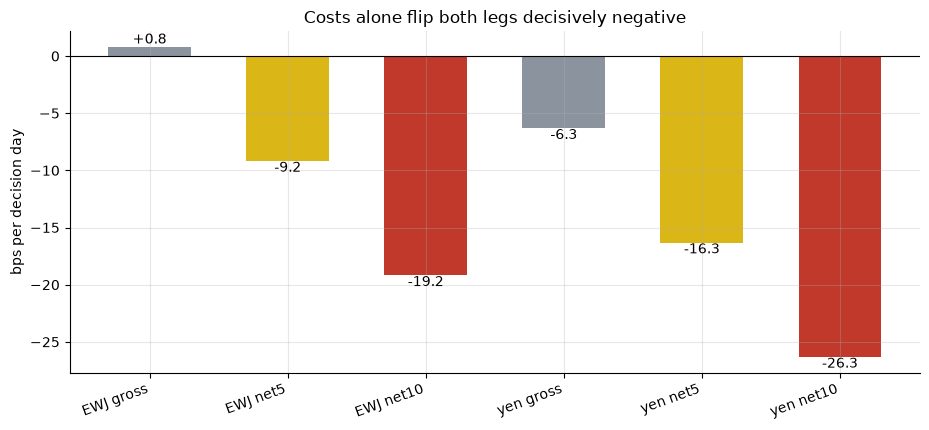

EWJ gross +0.80 -> net5 -9.20 / net10 -19.20 bps
yen gross -6.33 -> net5 -16.33 / net10 -26.33 bps


In [8]:
if HAVE_REAL:
    rows_e = [st.decision_day_capture(DF, 'ewj_ret', cost_bps=cb) for cb in (5.0, 10.0)]
    rows_j = [st.decision_day_capture(DF, 'jpy_ret', cost_bps=cb) for cb in (5.0, 10.0)]
    ge, n5e, n10e = rows_e[0]['gross_bps'], rows_e[0]['net_bps'], rows_e[1]['net_bps']
    gj, n5j, n10j = rows_j[0]['gross_bps'], rows_j[0]['net_bps'], rows_j[1]['net_bps']
else:
    ge, n5e, n10e = R['ewj_gross'], R['ewj_net5'], R['ewj_net10']
    gj, n5j, n10j = R['jpy_gross'], R['jpy_net5'], R['jpy_net10']
fig, ax = plt.subplots(figsize=(9.4, 4.4))
labels = ['EWJ gross','EWJ net5','EWJ net10','yen gross','yen net5','yen net10']
vals = [ge, n5e, n10e, gj, n5j, n10j]
cols = [GREY, AMBER, RED, GREY, AMBER, RED]
ax.bar(labels, vals, color=cols, width=.6)
ax.axhline(0, c='k', lw=.8)
for i,v in enumerate(vals): ax.annotate(f'{v:+.1f}',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.set_ylabel('bps per decision day')
ax.set_title('Costs alone flip both legs decisively negative')
plt.xticks(rotation=20, ha='right')
plt.tight_layout(); plt.show()
print(f'EWJ gross {ge:+.2f} -> net5 {n5e:+.2f} / net10 {n10e:+.2f} bps')
print(f'yen gross {gj:+.2f} -> net5 {n5j:+.2f} / net10 {n10j:+.2f} bps')

> 💡 In plain words: gross is already indistinguishable from zero (t = -0.06 EWJ, -0.85 yen). Add costs and both legs go decisively negative (-9.2 / -16.3 bps net at 5 bps). Worst single days: -8.1% (EWJ), -7.8% (yen) — H₅ is not just uncertified, it's actively negative-expectancy after costs. **Tradability = MIRAGE.**

### 4h · Faithful-engine & power control — we know the truth here

Synthetic i.i.d.-return world, scheduled pseudo-decisions every 12th business day, TUNABLE planted mean shift. The null (effect = 0) is checked over **20 seeds**.

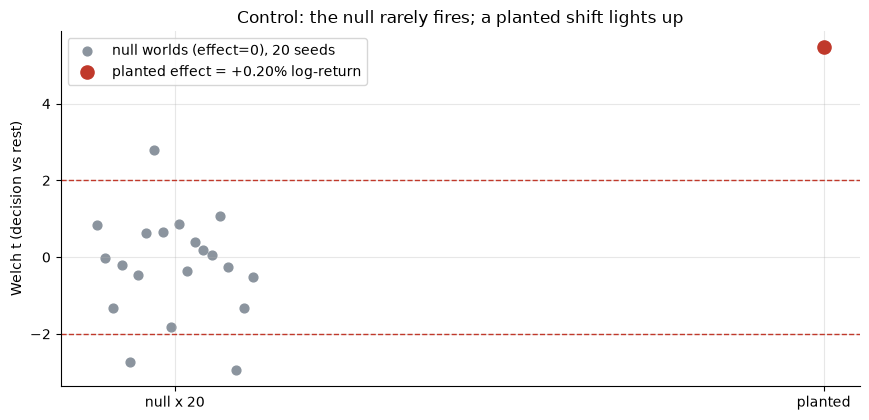

null: mean t = -0.23 (sd 1.34), |t|>=2 in 3/20 seeds  |  planted t = +5.46


In [9]:
null_ts = []
for s_ in range(20):
    close, dec = data.synthetic_world(effect=0.0, seed=646 + s_)
    null_ts.append(st.synthetic_detect(close, dec)['welch_t'])
null_ts = np.asarray(null_ts)
close, dec = data.synthetic_world(effect=0.002, seed=646)
planted_t = st.synthetic_detect(close, dec)['welch_t']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12,.12,20), null_ts, color=GREY, s=40,
           label='null worlds (effect=0), 20 seeds')
ax.scatter([1], [planted_t], color=RED, s=90, zorder=5,
           label='planted effect = +0.20% log-return')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('Welch t (decision vs rest)')
ax.set_title('Control: the null rarely fires; a planted shift lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds  |  planted t = {planted_t:+.2f}')

> 💡 In plain words: across 20 null worlds the detector fires in 3/20 seeds — a 100-seed check gives an empirical false-positive rate of 3%, consistent with the nominal ~5% for a single test, confirming the machinery is unbiased rather than systematically over-triggering. A planted +0.20% shift — far smaller than the ~2-4% tail-event moves above — reads t = 5.46, comfortably detected. The real-tape null (t ≈ -0.06 / -0.85) is the genuine article, not an underpowered test. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — EWJ decision-day +0.0080% vs +0.0145%: Welch t = **-0.06**; yen -0.0633% vs -0.0058%: Welch t = **-0.85**. Hit rates 47.8% / 47.4% (both below a coin flip), placebo p = 0.9223 / 0.1584, no event-window offset clears the bar, NIRP/YCC era-difference t = +0.13 / +0.75.
- **Tradability `MIRAGE`** — net -9.2 bps (EWJ) / -16.3 bps (yen) at 5 bps, worse at 10 bps; worst single days -8.1% / -7.8%.
- **"BoJ days swing more than average?" `CONFIRMED`** — realized range Welch t = **2.49** (EWJ) / **6.30** (yen). The folklore's honest kernel is amplitude, carried by a handful of huge, sign-flipping surprises that cancel on average — not a directional edge.

## 6 · Going further

- **The general lesson generalizes.** "A scheduled central-bank day moves the market" and "a scheduled central-bank day moves the market *in a knowable direction*" are separable claims; this study rejects the second while confirming the first (realized range).
- **Where the professional expression actually lives** is options (a long-gamma position through the decision, sized for the loud-but-directionless tail) rather than a directional cash position — the natural sequel study is a USDJPY-options straddle-through-BoJ-day backtest.
- **Dedup map:** [615-yen-safe-haven](../../615-yen-safe-haven/) (the yen's *general* risk-off reaction to any equity-crash day), [645-ecb-announcement-effect](../../645-ecb-announcement-effect/) (the same question for the ECB), [637-fomc-vol-crush](../../637-fomc-vol-crush/) (the Fed's decision-day effect on *implied vol*, scheduled meetings only).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*